# Introduction to SoccerTrack

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](ここに以下の書式でURLを入れる) 
[![github](https://badgen.net/badge/:status/View%20On%20Github/black?icon=github&label)](https://github.com/AtomScott/SoccerTrack)
[![badge](https://img.shields.io/badge/launch-binder-579ACA.svg?logo=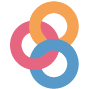)](https://)

---

This quick tutorial introduces the key concepts and basic features of GeoPandas to help you get started with your projects.

## Concepts

### Multiple Object Tracking in SoccerTrack

In a broad definition, Multiple Object Tracking (MOT) is the problem of automatically identifying multiple objects in a video and representing them as a set of trajectories. 

The typical approach to MOT algorithms follows the tracking-by-detection paradigm, which attempts to solve the problem by first detecting objects in each frame and then associating them with the objects in the previous frame.

One large challenge in the tracking-by-detection paradigm is scalability. The detection model is typically a deep learning model, which is computationally expensive. The association model is also computationally expensive, as it requires reID features to be extracted for each bounding box. Recent approaches, such as [TrackFormer](https://arxiv.org/abs/2101.02702)/[TransTrack](https://arxiv.org/abs/2012.15460), have attempted to address this challenge by using a single deep learning model to perform both detection and association. However, there is no clear consensus on the best approach to MOT as tracking-by-detection models are still competitive ([ByteTrack](https://arxiv.org/abs/2110.06864)/[BoT-SORT](https://arxiv.org/abs/2206.14651)/[Strong-SORT](https://arxiv.org/abs/2202.13514)).


> IMHO, approaches that adhere to “The Bitter Lesson” are the most promising. [Unicorn: Towards Grand Unification of Object Tracking](https://arxiv.org/abs/2207.07078) demonstrates that a single network can solve four tracking problems (SOT, MOT, VOS, MOTS) simultaneously. I think this is a direction many will follow.

SoccerTrack implements the tracking-by-detection paradigm. 

In brief, the algorithm works as follows:

1. The detection model (YOLOX, DETR, RCNN etc.) detects items of interest via bounding boxes in each frame, then 
2. Several feature extractors are used to obtain descripters of each detection (e.g. ReID features, optical flow features, etc.), then
3. The association model (Minimum cost bipartite matching) associates detections in the current frame with detections in the previous frame / existing tracklets.

For a more detailed explanation of the tracking-by-detection paradigm, please refer to the original [DeepSORT paper](https://arxiv.org/abs/1703.07402), [this blog](https://medium.com/augmented-startups/deepsort-deep-learning-applied-to-object-tracking-924f59f99104) explaining DeepSORT or our [SoccerTrack paper](https://openaccess.thecvf.com/content/CVPR2022W/CVSports/papers/Scott_SoccerTrack_A_Dataset_and_Tracking_Algorithm_for_Soccer_With_Fish-Eye_CVPRW_2022_paper.pdf).

![](assets/tracking-by-detection.png)

We chose to start with this approach for two reasons: 1) it is a simple and modular approach and 2) we can explicitly control the use of appearance and motion features. 

### SoccerTrack DataFrame

SoccerTrack extends the popular data science library [pandas](https://pandas.pydata.org/) by adding an interface to handle tracking data. If you are not familiar with [pandas](https://pandas.pydata.org/), we recommend taking a quick look at its [Getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) documentation before proceeding.

There are two core data structures in SoccerTrack, the BoundingBoxDataFrame and the CoordinateDataFrame. Both are,

   1. Subclasses of pandas.DataFrame and inherit all of its functionality
   2. Inherited from the SoccerTrackMixin and are designed to work with the SoccerTrack API

![](./assets/dataframe_inheritance.png)

The main difference is that the CoordinateDataFrame has comes built-in with functionality that handles coordinates, while the BoundingBoxDataFrame is made to be compatibile with bounding box data. Other than that, they are similar and can be approximately transformed into each other using the `to_coordinates` and `to_bounding_boxes` methods. However, a HomoGraphy is required to perform this transformation. See how to obtain a Homography in the [Camera Calibration]() tutorial.

In a nutshell, both data structures are a multi-indexed pandas.DataFrame with a few extra methods and attributes/metadata. 

![soccertrack_dataframe](./assets/soccertrack_dataframe.png)

Let’s see how some of these concepts work in practice.

## Reading and writing files

First, we need to read some data.

### Reading files

Assuming you have a file containing either bounding box or coordinates data, you can read it using `soccertrack.read_data()`, which automatically detects the filetype and creates a `BBoxDataFrame` or a `CoordinateDataFrame`. This tutorial uses a sample from the SoccerTrack dataset, which is part of the SoccerTrack installation. Therefore, we use `soccertrack.datasets.get_path()` to retrieve the path to the dataset.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import soccertrack
from soccertrack.logging import show_df # This just makes the df viewable in the notebook.

path_to_csv = soccertrack.datasets.get_path('soccertrack sample', type='csv')
bbdf = soccertrack.load_df(path_to_csv)

print(type(bbdf))
show_df(bbdf.head())

<class 'soccertrack.dataframe.bboxdataframe.BBoxDataFrame'>


/home/guest/dev_repo/SoccerTrack/soccertrack/datasets/soccertrack_sample.csv


To use the full soccertrack dataset, see ["Dataset Preparation"](../../01_get_started/dataset_preparation.html).

### Writing files

To write back to file use `BBoxDataFrame.to_csv()`. 

In [3]:
bbdf.to_csv("soccertrack_sample.csv")

## Simple accessors and methods

Since the `BBoxDataFrame` and `CoordinateDataFrame` are subclasses of `pandas.DataFrame`, they inherit all of its functionality. This means that you can use all of the standard `pandas.DataFrame` methods and accessors. 

For example,

* `df.head()` returns the first 5 rows of the dataframe
* `df.columns` returns the column names
* `df.iloc[0]` returns the first row of the dataframe

In [4]:
# bbdf.head() is used above!

print(bbdf.columns[0])

show_df(bbdf.iloc[[0]])

('0', '1', 'bb_left')


Note that these are MultiIndex dataframes, so you can use more advanced indexing methods, such as `df.xs`.

In this example, 

* df.xs('0', level='TeamID', axis=1) returns the first team's data
* df.xs('5', level='PlayerID', axis=1) returns the data for player 5 in all teams
* df.xs(('0', '5'), level=('TeamID', 'PlayerID'), axis=1) returns the data for player 5 in team 0

In [5]:
show_df(bbdf.xs('0', level='TeamID', axis=1).head(3))

In [6]:
show_df(bbdf.xs('5', level='PlayerID', axis=1).head(3))

In [7]:
show_df(bbdf.xs(('0', '5'), level=('TeamID', 'PlayerID'), axis=1).head(3))

Attributes,bb_left,bb_top,bb_width,bb_height,conf
frame,,,,,
0,3761.640000,612.480000,33.440000,63.150000,1.000000
1,3761.640000,612.480000,33.440000,63.150000,1.000000
2,3762.060000,612.540000,33.430000,63.160000,1.000000


### Visualizing the results

Now that we have a bounding box dataframe, we can visualize the results.

To perform visualization we need to download a video from the SoccerTrack dataset. We can use `soccertrack.datasets.get_path()` show the download link.

In [8]:
soccertrack.datasets.get_path('soccertrack sample', type='mp4')

get_path:0035  💬| Download the dataset from https://drive.google.com/file/d/1Vxc1NXwLiD3T6cqmlbjgjr-9umDty5Va/view?usp=sharing 


'https://drive.google.com/file/d/1Vxc1NXwLiD3T6cqmlbjgjr-9umDty5Va/view?usp=sharing'

Click the link and download the video. For ease, move it into the save folder as this notebook.

In [9]:
path_to_mp4 = 'soccertrack_sample.mp4'

It is also possible to download full soccertrack dataset using `soccertrack.datasets.Downloader`. See ["Dataset Preparation"](./dataset_preparation.html) for more details.

The `BBoxDataFrame` has a built-in `visualize_frame()` method that can be used to visualize the bounding boxes in a single frame.

visualize_frame:0108  🤔| NaN value found at frame 0, team 1, player 11. Skipping... 
visualize_frame:0108  🤔| NaN value found at frame 0, team 3, player 0. Skipping... 


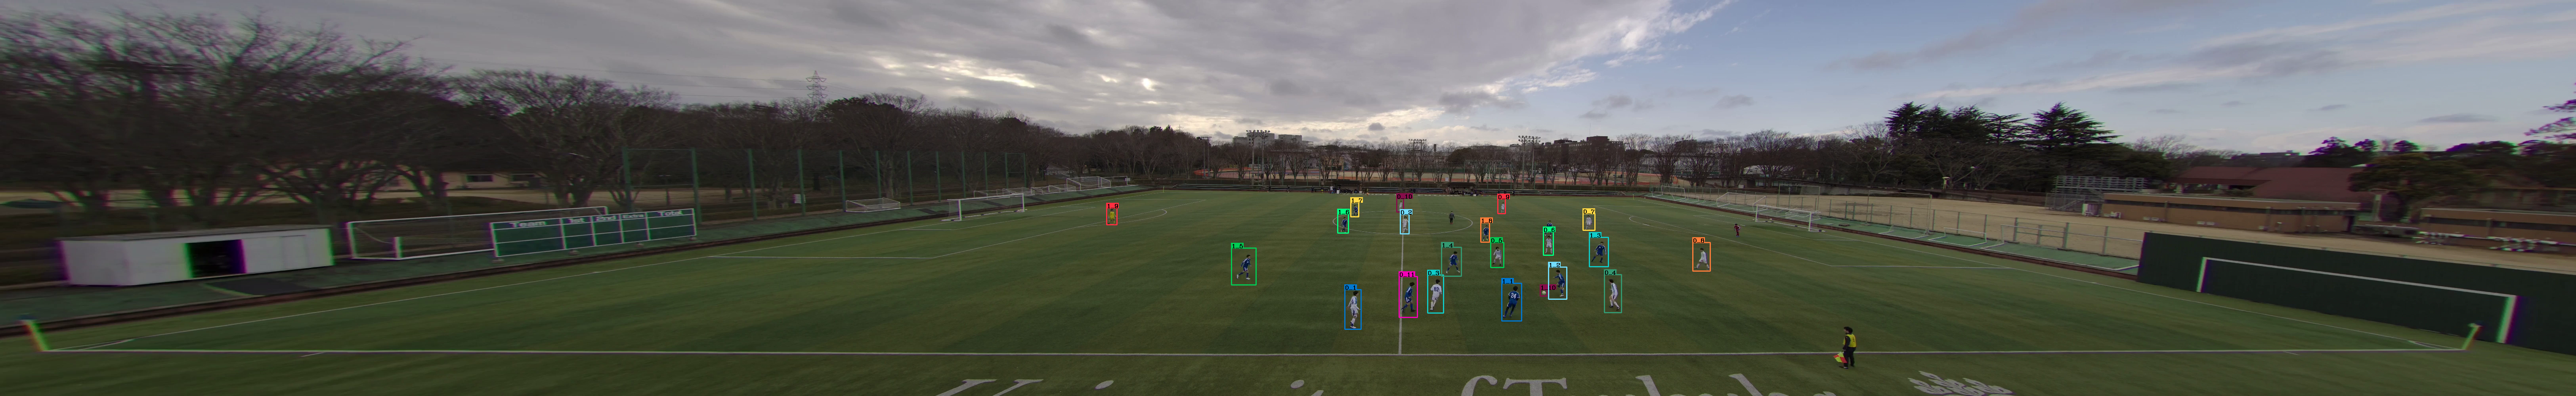

In [10]:
from soccertrack import Camera
from soccertrack.utils import cv2pil

frame = next(Camera(path_to_mp4).iter_frames())
cv2pil(bbdf.visualize_frame(frame_idx=0, frame=frame))

The `BBoxDataFrame` also has a `visualize_bbox()` method built in. It returns  generators containing a sequence of drawn bounding boxes, which can be passed to the `make_video` method of `soccertrack.utils` to output a video. 

The following notebook will output `bbox_FISH.mp4` in the current directory.

In [ ]:
save_path = './bbox_FISH.mp4'
bbdf.visualize_frames(path_to_mp4, save_path)

## Tracking

Below we provide a snippiet of code that detects and tracks the players and ball in the downloaded video. First we define the components of our tracking pipeline. In SoccerTrack, there are five core components:

- `Camera` - A class that handles camera calibration and coordinate transformations
- `DetectionModel`: A detection model, such as YOLOX, DETR, etc. 
- `FeatureExtractor`: A feature extractor, such as ReID, Optical Flow, etc.
- `AssociationModel`: An association model, such as Minimum Cost Bipartite Matching, etc.
- `TrackingModel`: A object which stores which combines the above components and handles the tracking logic.

In this example, we select the following components:

- `DetectionModel`: YOLOX
- `FeatureExtractor`: ReID, Optical Flow
- `AssociationModel`: Minimum Cost Bipartite Matching

`Camera` and `TrackingModel` are created using the default SoccerTrack parameters. See the [Core Components](./core_components.html) tutorial for more details on each component.

> Deciding how to architect the structure of the tracking part was very tricky and probably suboptimal. We are still working on improving this part of the library so there may be some breaking changes in the future.

In [11]:
from soccertrack import Camera
from soccertrack.logging import tqdm
from soccertrack.pipeline import get_fe_pipe, get_matching_fn, get_tracking_model, get_detection_model

cam = Camera(path_to_mp4)

# define the object detection model
det_model = get_detection_model('yolov5s')

# define the feature extraction process (FEP) pipeline
# this will extract appearance features from the detections
fe_pipe = get_fe_pipe(['resnet18', 'bbox'])

# define the detection-tracklet matching function
matching_fn = get_matching_fn(metrics=['', 'iou'], weights=[], gates=[])

# define the tracking model
mot_model = get_tracking_model(
    model_spec={'model': 'kalman tracker', 'n_trackers': {22}}, 
    matching_fn=matching_fn,
    tracker_kwargs={'dt': 1/25}
    )

In [12]:
for frame in cam.iter_frames():
    
    # detect objects using the detection model
    detections = det_model.predict(frame)
    
    # extract features from the detections using the FEP pipeline
    detections = fe_pipe.transform(detections)
    
    # update the state of the multi-object-tracker tracker
    # with the list of bounding boxes
    mot_model.step(detections)

    # retrieve the active tracks from the tracker (you can customize
    # the hyperparameters of tracks filtering by passing extra arguments)
    tracks = mot_model.active_tracks()

> Note that we import `logger` and `tqdm` from `soccertrack.logging`. SoccerTrack uses its own logging module to provide more informative messages. This is not necessary, but it is recommended. See the [Logger Usage](../04_dev/logging-demo.html) tutorial for more details.

## What next?

In the next tutorial, we will learn how to calibrate the camera, which is necessary to convert between pixel coordinates and real world coordinates. SoccerTrack implements the tracking-by-detection paradigm.

> This tutorial is a work in progress. If you have any questions or suggestions, please feel free to [reach out](https://twitter.com/AtomJamesScott).
> 
> We were heavily inspired by the wonderful [GeoPandas](https://geopandas.org/) documentation. Kudos to the GeoPandas team for their great work!